In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan


# Remove null values df. dropna(inplace=True)

# if variables are changed on the fly 
# from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Analysis

In [3]:
N_PASTS, n_lags, n_perm = list(range(1, 4)), 1, 1000
alpha, beta = 0.01, 0.001

In [4]:
# os.chdir(r'./data/Sachs_data/')
names = [n for n in os.listdir() if n.endswith('.xls')]
INFs = {}
for i in range(len(names)):
    data = pd.read_excel(names[i])
    print(data.columns)

In [5]:
%%time

# load data
os.chdir(r'./data/Sachs_data/')
names = [n for n in os.listdir() if n.endswith('.xls')]
INFs = {}
for i in range(len(names)):
    data = pd.read_excel(names[i])
    X_ = data.values
    X = X_.T
    print('Data ' + names[i])
    print('')
    
    # Analysis
    infs = []
    for a, n in enumerate(N_PASTS):
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0, beta=0, simulation=False)
        np.fill_diagonal(inf, 0)
        infs.append(inf)
        # gcstar.plot_extended_connectivity_matrix(alpha = 0.01, beta = 0.001)

    print('')
    print('')
    INFs[i] = infs

Data 6. cd3cd28+u0126.xls

1 pasts
2 pasts
3 pasts


Data 1. cd3cd28.xls

1 pasts
2 pasts
3 pasts


Data 10. cd3cd28icam2+aktinhib.xls

1 pasts
2 pasts
3 pasts


Data 2. cd3cd28icam2.xls

1 pasts
2 pasts
3 pasts


Data 13. cd3cd28icam2+u0126.xls

1 pasts
2 pasts
3 pasts


Data 8. pma.xls

1 pasts
2 pasts
3 pasts


Data 3. cd3cd28+aktinhib.xls

1 pasts
2 pasts
3 pasts


Data 14. cd3cd28icam2+ly.xls

1 pasts
2 pasts
3 pasts


Data 4. cd3cd28+g0076.xls

1 pasts
2 pasts
3 pasts


Data 11. cd3cd28icam2+g0076.xls

1 pasts
2 pasts
3 pasts


Data 9. b2camp.xls

1 pasts
2 pasts
3 pasts


Data 7. cd3cd28+ly.xls

1 pasts
2 pasts
3 pasts


Data 5. cd3cd28+psitect.xls

1 pasts
2 pasts
3 pasts


Data 12. cd3cd28icam2+psit.xls

1 pasts
2 pasts
3 pasts


CPU times: user 7min 18s, sys: 6.47 s, total: 7min 24s
Wall time: 7min 28s


In [6]:
np.transpose(np.where(INFs[1][1]!=0))

array([[ 0,  1],
       [ 1,  0],
       [ 3,  4],
       [ 4,  3],
       [ 5,  6],
       [ 5,  7],
       [ 6,  5],
       [ 6,  7],
       [ 7,  5],
       [ 7,  6],
       [ 8,  9],
       [ 8, 10],
       [ 9,  8],
       [10,  8]])

In [7]:
pro = ['Raf', 'Mek', 'P1cy', 'PIP2', 'PIP3', 'p44/42', 'Akt', 'PKA', 'PKC', 'p38', 'Jnk']

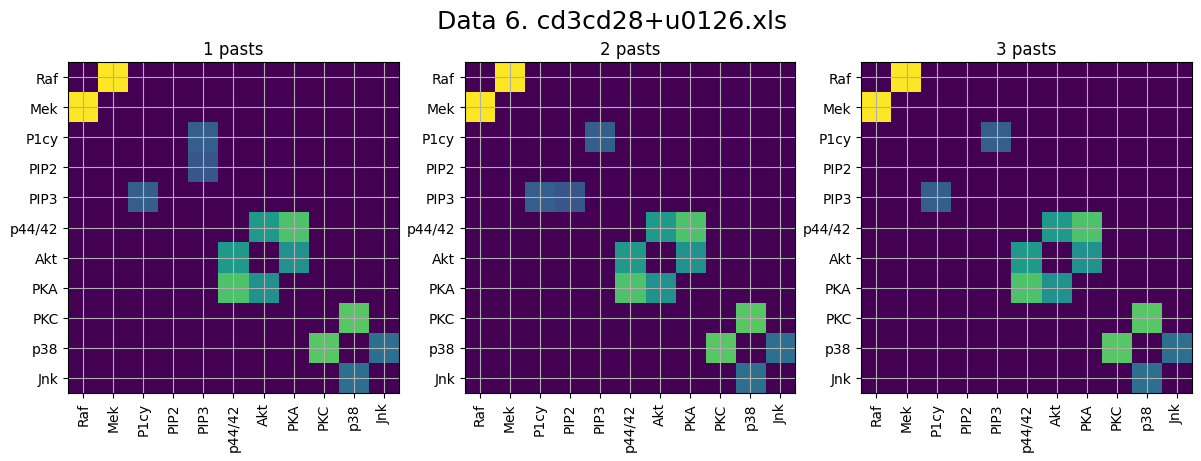

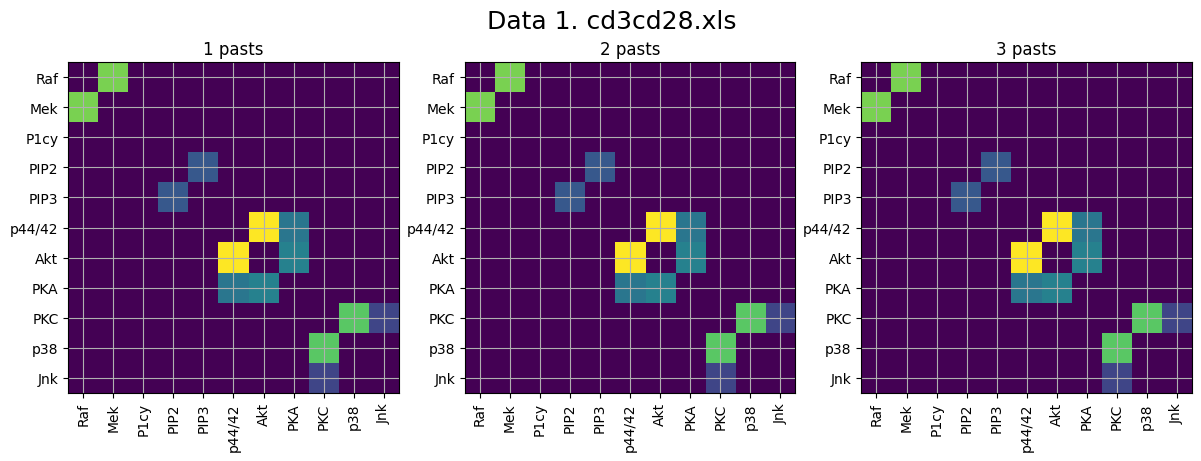

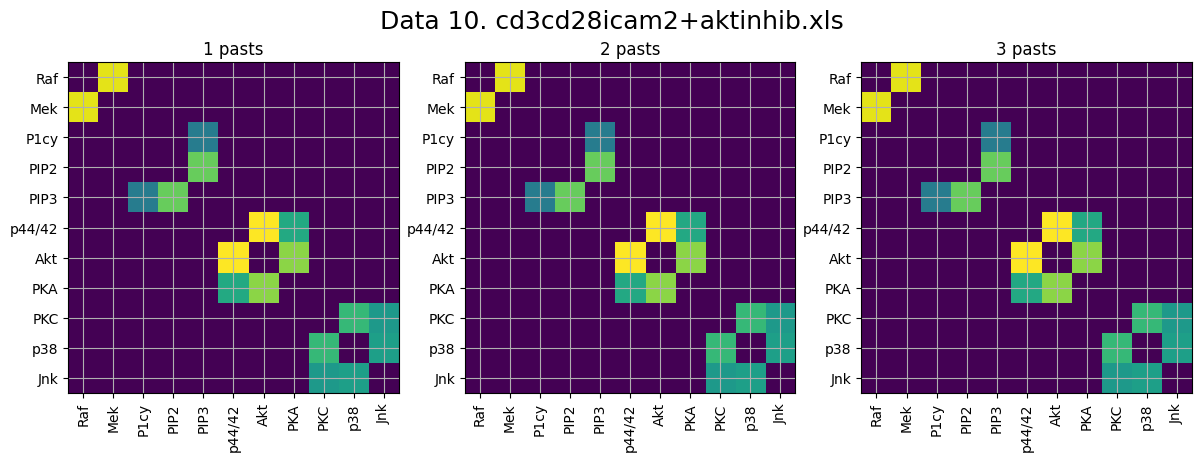

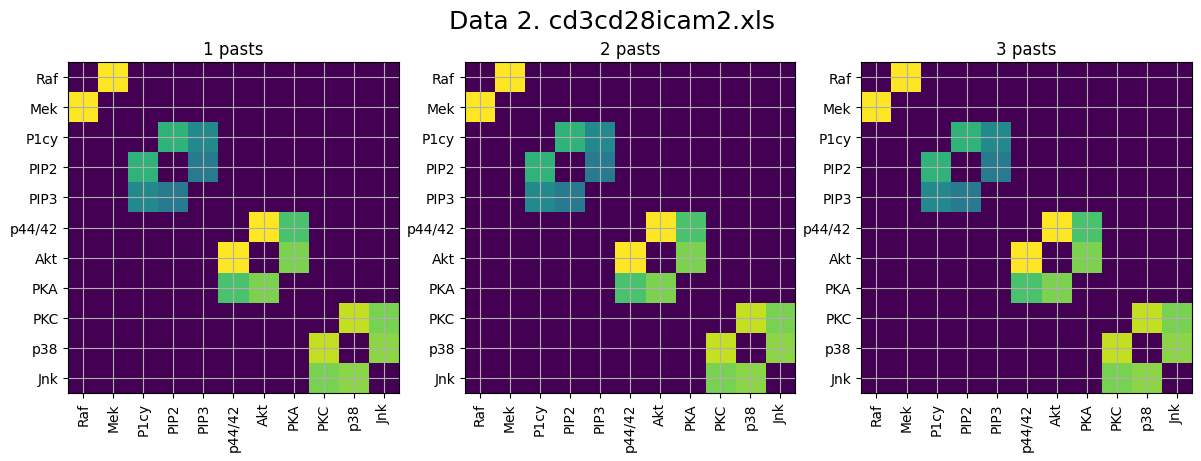

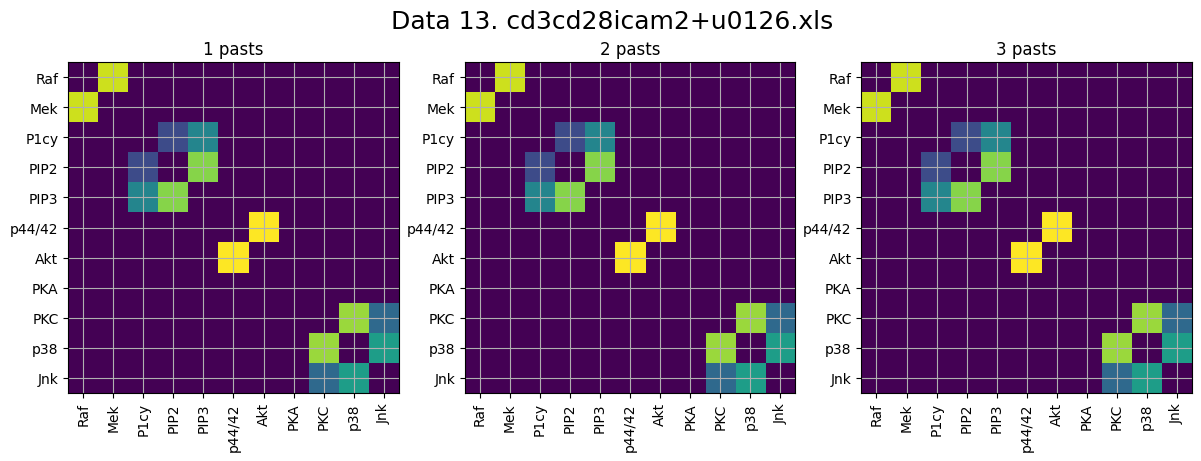

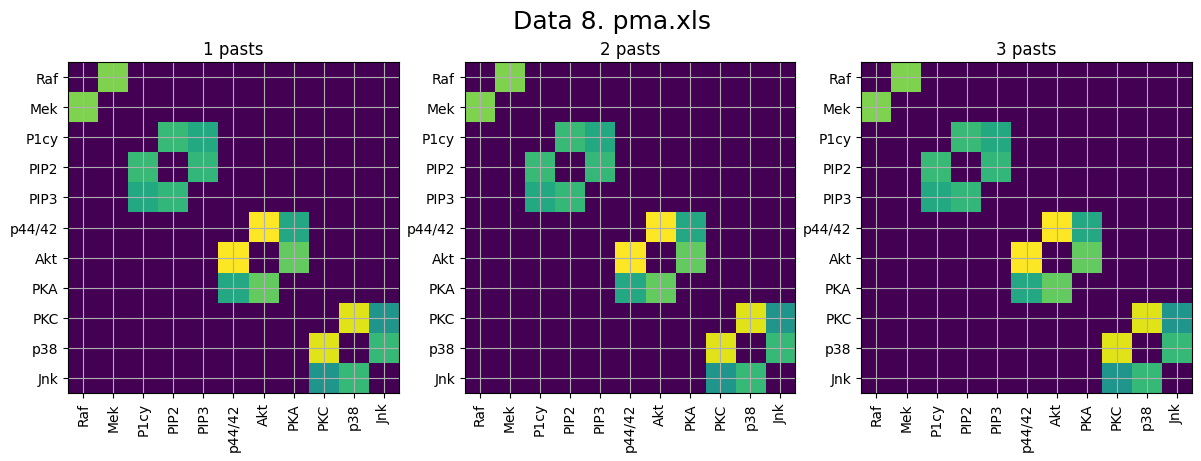

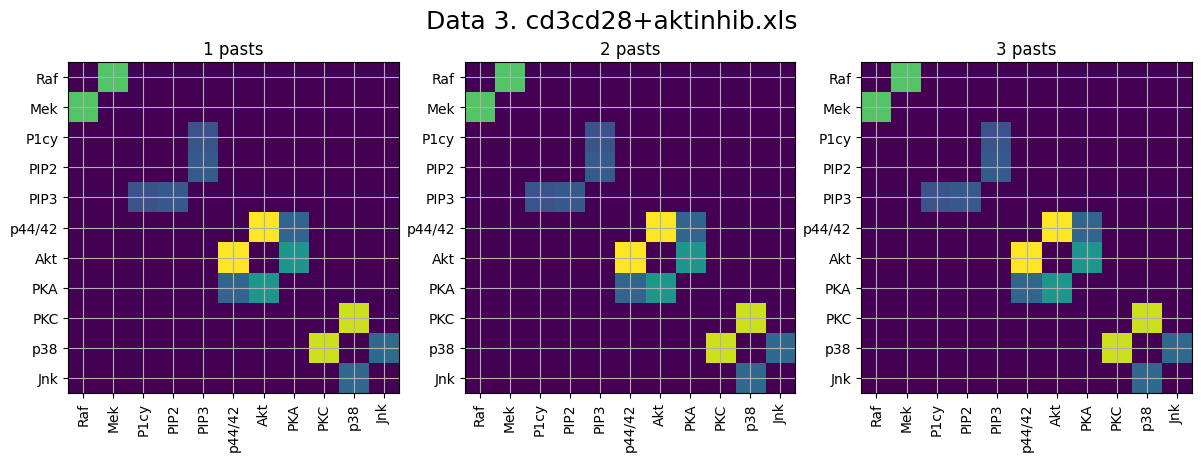

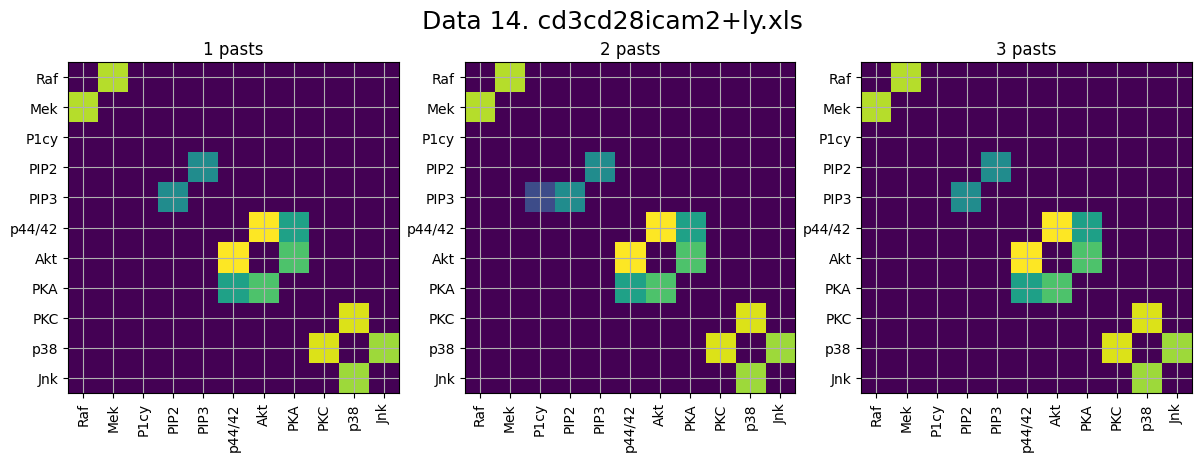

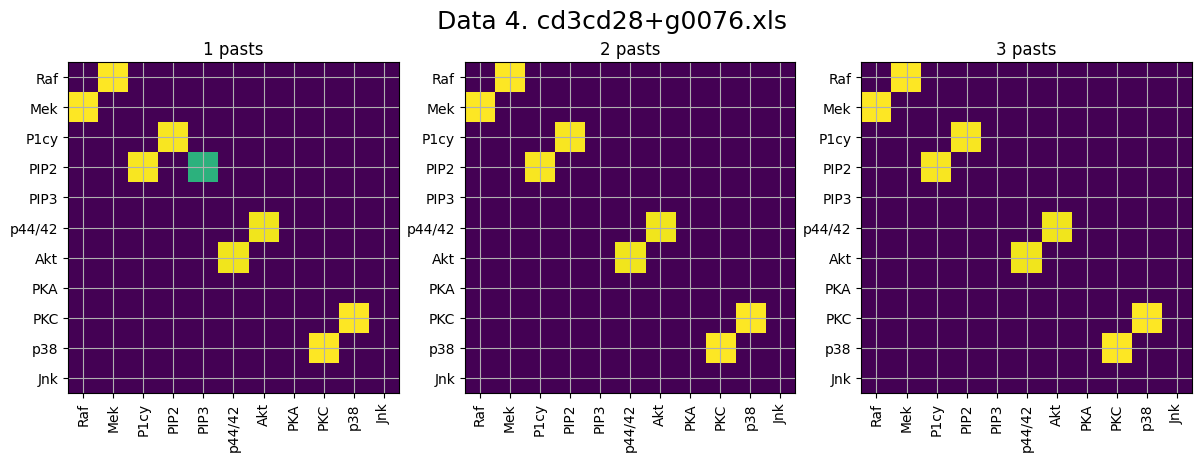

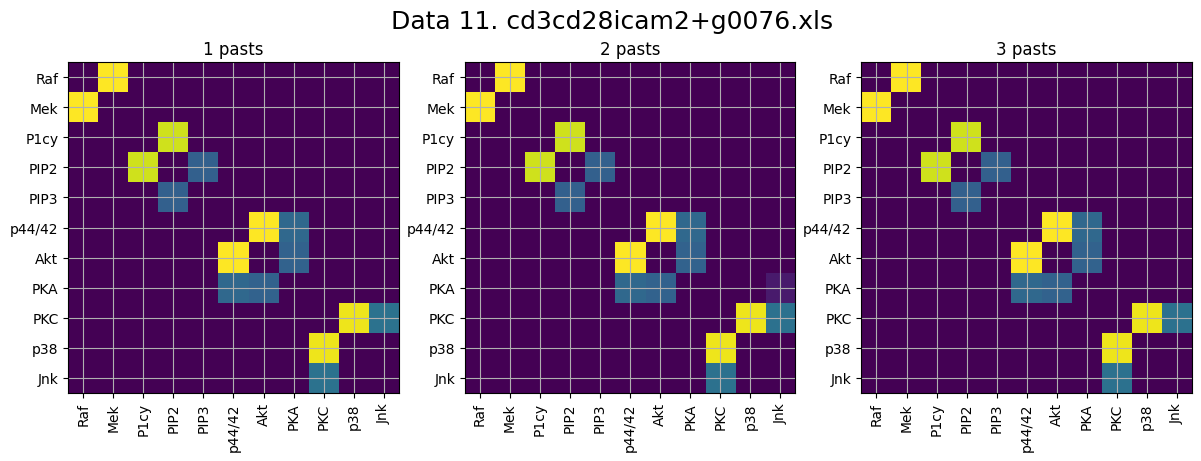

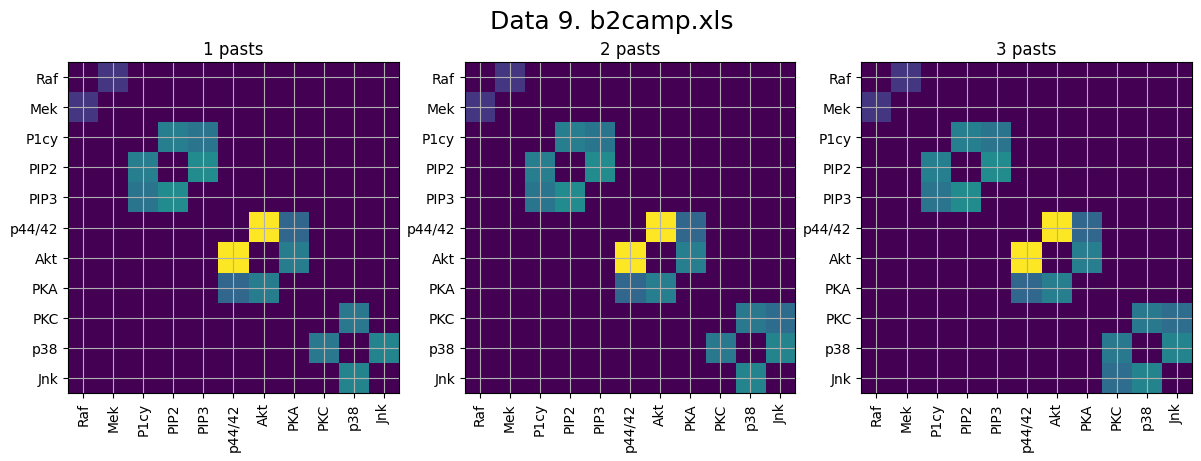

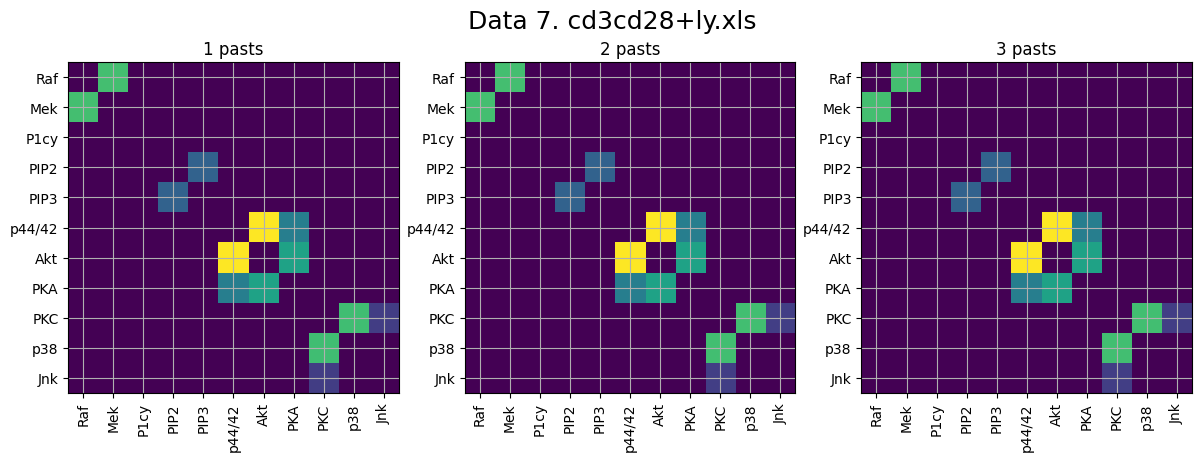

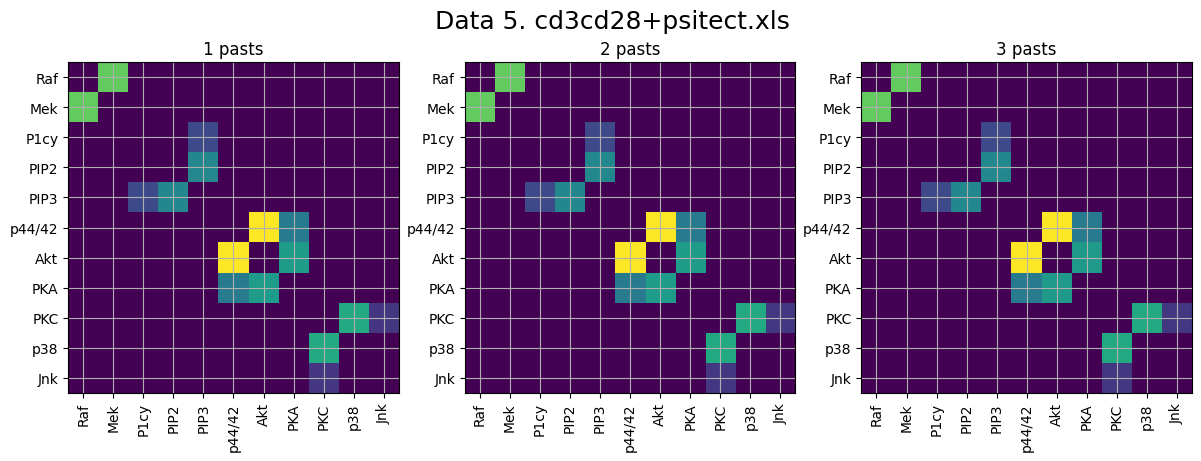

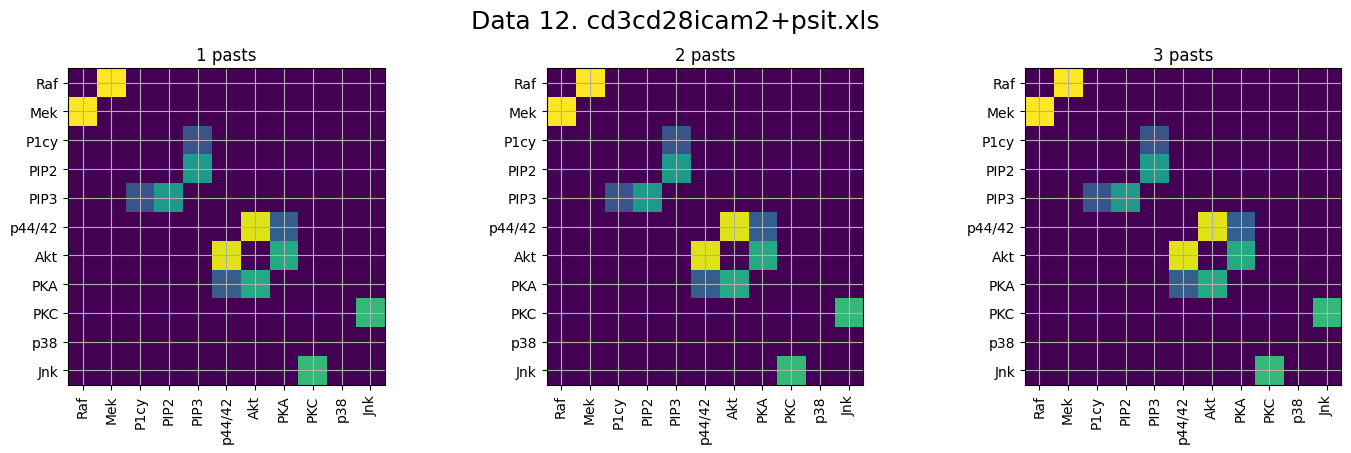

In [8]:
for i in range(14):
  fig,ax = plt.subplots(1,3,figsize=(14.5,4.5))
  for j in range(3):
    ax[j].imshow(INFs[i][j])
    ax[j].set_title(f'{j+1} pasts')
    ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
    ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
    ax[j].set_xticklabels(pro,rotation=90)
    ax[j].set_yticklabels(pro)
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
  # print('')
  # print('')
plt.tight_layout()

In [9]:
stop

NameError: name 'stop' is not defined

In [10]:


from cdt.metrics import SHD
from numpy.random import randint
tar, pred = randint(2, size=(10, 10)), randint(2, size=(10, 10))
SHD(tar, pred, double_for_anticausal=False)

<unknown>:177: SyntaxWarning: invalid escape sequence '\d'
<unknown>:176: SyntaxWarning: invalid escape sequence '\d'

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sadiqadedayo/miniforge3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sadiqadedayo/miniforge3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users

np.float64(37.0)